<a href="https://colab.research.google.com/github/sgl13/Machine_Learning/blob/main/Unsupervised_Kmeans_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**K-Means Clustering**

unsupervised machine learning algorithm used to group an unlabeled dataset into $K$ distinct, non-overlapping clusters based on feature similarity.

Initialization: Select $K$ initial points at random as cluster centroids.Assignment: Assign each data point to the nearest centroid, usually using Euclidean distance:

Update: Recalculate each centroid by taking the mean of all data points assigned to that cluster.

Convergence: Repeat the assignment and update steps until centroids no longer change position or a maximum number of iterations is reached.

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [2]:
X,y=make_blobs(n_samples=1000,centers=3,n_features=2)

In [3]:
X

array([[-0.99945529, -7.12430476],
       [ 8.78870465,  5.94297816],
       [-3.37264391, -3.38945131],
       ...,
       [-2.35110301, -4.64975179],
       [-2.45684606, -3.77592211],
       [ 0.18792005, -9.19802885]])

In [4]:
y

array([2, 0, 2, 1, 2, 0, 1, 1, 0, 0, 2, 0, 1, 2, 1, 0, 1, 0, 1, 2, 2, 2,
       0, 2, 1, 1, 0, 2, 0, 1, 0, 0, 0, 2, 0, 0, 1, 2, 1, 1, 0, 1, 2, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 2, 2, 2, 1, 1, 1, 2, 2, 1, 0, 2, 1, 0, 2,
       1, 1, 1, 0, 2, 2, 1, 1, 0, 2, 0, 0, 0, 0, 2, 2, 1, 0, 0, 1, 1, 0,
       1, 1, 1, 2, 2, 1, 2, 0, 1, 1, 2, 1, 2, 2, 2, 2, 0, 0, 1, 0, 1, 2,
       1, 1, 2, 0, 2, 2, 0, 1, 2, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 2, 0, 2,
       0, 0, 2, 1, 1, 2, 1, 1, 1, 1, 0, 2, 2, 2, 1, 0, 2, 0, 1, 2, 0, 2,
       0, 0, 1, 1, 1, 2, 2, 1, 1, 1, 2, 0, 0, 0, 2, 0, 1, 0, 1, 2, 0, 1,
       1, 1, 1, 0, 0, 1, 0, 2, 2, 0, 1, 2, 2, 2, 2, 1, 0, 1, 1, 2, 1, 0,
       2, 0, 0, 2, 0, 0, 2, 2, 0, 0, 1, 2, 1, 2, 1, 2, 0, 1, 0, 2, 1, 0,
       1, 2, 2, 1, 1, 1, 0, 1, 1, 0, 2, 1, 1, 0, 2, 0, 1, 0, 0, 1, 2, 0,
       0, 0, 0, 1, 1, 0, 2, 0, 1, 2, 1, 2, 1, 2, 0, 0, 0, 1, 0, 2, 0, 1,
       0, 0, 1, 0, 0, 2, 1, 0, 0, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 2, 0, 0,
       2, 0, 1, 1, 2, 2, 0, 2, 2, 2, 2, 2, 0, 1, 1,

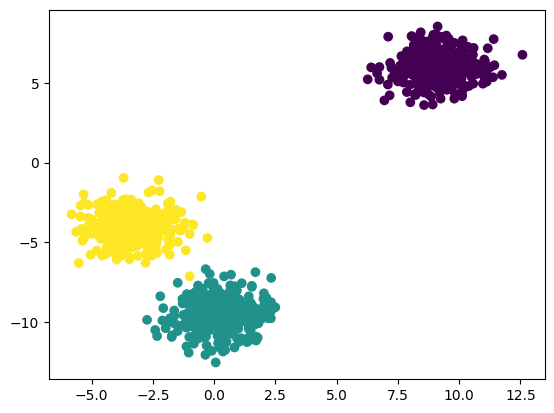

In [5]:
plt.scatter(X[:,0],X[:,1],c=y)

In [6]:
## standardization--feature scaling technique
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [9]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [10]:
from sklearn.cluster import KMeans

In [11]:
## Elbow method To select K Value
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [12]:
wcss

[1339.9999999999984,
 164.8275441403096,
 38.49244570553543,
 33.99883720880599,
 28.2803791310555,
 23.684576045974016,
 23.988813466371933,
 20.150373346627134,
 17.575652208242534,
 15.225791229199638]

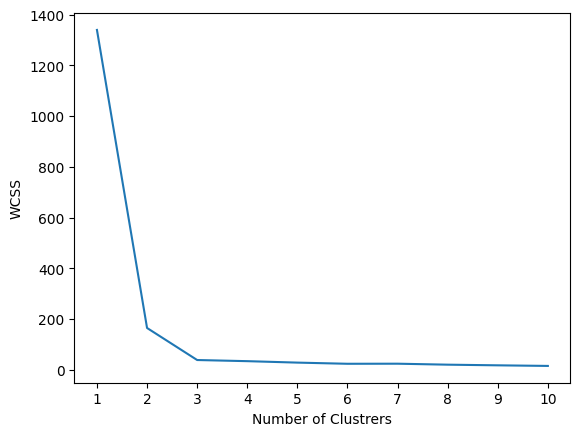

In [13]:
## plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clustrers")
plt.ylabel("WCSS")
plt.show()

In [14]:
kmeans=KMeans(n_clusters=3,init="k-means++")

In [15]:
kmeans.fit_predict(X_train_scaled)

array([2, 1, 1, 1, 1, 0, 2, 2, 2, 0, 0, 1, 1, 1, 1, 1, 0, 2, 1, 0, 1, 2,
       0, 0, 2, 2, 1, 0, 2, 2, 0, 2, 1, 2, 2, 0, 0, 1, 0, 1, 0, 2, 1, 2,
       1, 0, 1, 1, 1, 2, 0, 2, 1, 2, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 2, 1,
       1, 0, 0, 2, 1, 1, 0, 1, 1, 0, 1, 0, 0, 2, 2, 1, 2, 0, 0, 2, 1, 0,
       2, 2, 1, 0, 1, 1, 2, 0, 0, 0, 2, 0, 0, 2, 1, 0, 2, 1, 0, 0, 0, 0,
       1, 2, 0, 0, 0, 0, 2, 1, 0, 1, 0, 2, 1, 1, 2, 2, 1, 0, 0, 1, 0, 0,
       2, 0, 0, 0, 2, 0, 1, 0, 1, 2, 2, 1, 1, 0, 1, 1, 0, 2, 0, 2, 0, 1,
       1, 0, 2, 1, 0, 2, 2, 0, 0, 2, 0, 1, 0, 0, 2, 1, 1, 1, 0, 0, 2, 0,
       2, 1, 2, 2, 0, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 0, 1, 2, 1, 0, 0, 0,
       2, 1, 1, 1, 2, 0, 1, 2, 2, 2, 1, 2, 2, 0, 1, 2, 1, 0, 0, 2, 0, 0,
       0, 0, 1, 1, 1, 0, 1, 0, 0, 2, 2, 1, 1, 2, 1, 2, 0, 2, 2, 2, 0, 0,
       1, 0, 2, 1, 0, 2, 0, 1, 0, 2, 2, 1, 2, 1, 2, 2, 1, 1, 1, 2, 0, 2,
       2, 0, 0, 2, 0, 0, 0, 1, 1, 2, 1, 0, 2, 2, 1, 0, 0, 1, 2, 1, 1, 0,
       1, 2, 0, 1, 1, 1, 0, 0, 1, 2, 0, 2, 2, 0, 2,

In [16]:
y_pred=kmeans.predict(X_test_scaled)

In [17]:
y_pred

array([1, 1, 2, 2, 1, 0, 1, 2, 0, 1, 0, 0, 2, 0, 1, 0, 1, 1, 1, 1, 2, 0,
       0, 2, 1, 0, 2, 2, 1, 1, 2, 1, 0, 1, 0, 2, 0, 0, 2, 2, 1, 1, 2, 1,
       1, 2, 1, 2, 1, 2, 1, 1, 2, 0, 2, 0, 0, 2, 2, 0, 2, 2, 0, 2, 0, 0,
       0, 2, 2, 1, 0, 0, 2, 2, 0, 1, 2, 1, 2, 0, 1, 1, 2, 1, 0, 0, 2, 1,
       1, 2, 1, 2, 1, 1, 0, 1, 1, 1, 1, 2, 0, 2, 1, 0, 1, 0, 1, 1, 2, 1,
       0, 2, 0, 2, 1, 2, 2, 2, 2, 2, 1, 2, 1, 0, 0, 2, 2, 0, 0, 1, 1, 1,
       0, 0, 2, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 2, 0, 2, 0, 0, 1, 1, 0,
       1, 0, 0, 1, 1, 2, 2, 1, 0, 2, 2, 2, 0, 2, 1, 2, 0, 0, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 0, 2, 2, 1, 0, 2, 1, 2, 2, 1, 0, 2, 2, 2, 1,
       0, 0, 1, 0, 0, 2, 1, 1, 0, 2, 1, 1, 2, 1, 2, 2, 2, 1, 2, 0, 2, 2,
       2, 0, 1, 0, 0, 2, 0, 2, 1, 2, 1, 0, 0, 1, 2, 0, 1, 2, 0, 2, 1, 2,
       0, 0, 2, 2, 1, 0, 0, 2, 1, 0, 2, 0, 2, 2, 2, 2, 0, 0, 0, 2, 1, 1,
       2, 0, 0, 1, 0, 0, 0, 2, 0, 1, 2, 0, 1, 1, 2, 0, 0, 1, 1, 2, 2, 0,
       1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 2, 1, 1, 0, 1,

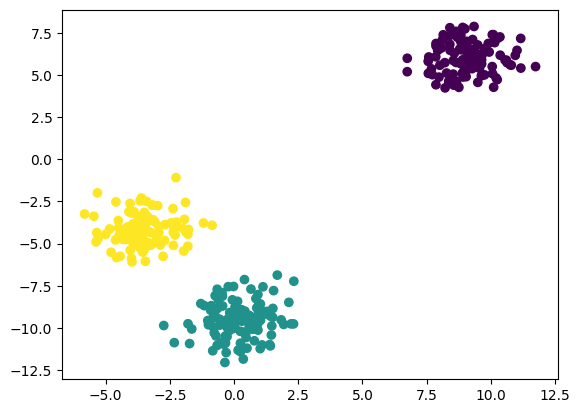

In [18]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)